# **Impor Pustaka**

In [1]:
!pip install roboflow ultralytics
from roboflow import Roboflow
from ultralytics import YOLO
import os
import glob
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import Image, display
import random
import cv2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 108.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependenc

# **1. Akuisisi Data**

In [2]:
rf = Roboflow(api_key="dUJo6cQS0aGViQ30r4Qt")
project = rf.workspace("ahmad-farhan-hidayat-s-workspace").project("fish-freshness-0by5o-nqtfg")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fish-Freshness-3 in yolov8:: 100%|██████████| 9479/9479 [00:12<00:00, 777.20it/s] 


# **2. Analisis Data Eksploratif**

## 2.1 Total *Bounding Box*

In [3]:
sns.set_theme(style="whitegrid", palette="muted")

LABEL_DIR = "/kaggle/working/Fish-Freshness-3/train/labels"
CLASS_NAMES = {
    0: "Fresh-Eye", 
    1: "Fresh-Skin", 
    2: "NonFresh-Eye", 
    3: "NonFresh-Skin"
}

def load_yolo_labels(label_dir):
    all_data = []
    txt_files = glob.glob(os.path.join(label_dir, "*.txt"))
    
    for file in txt_files:
        with open(file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:])
                    
                    bbox_area = width * height
                    aspect_ratio = width / height if height > 0 else 0
                    
                    all_data.append([
                        CLASS_NAMES.get(class_id, f"Class {class_id}"), 
                        x_center, y_center, width, height, bbox_area, aspect_ratio
                    ])
                    
    df = pd.DataFrame(all_data, columns=["Class", "X_Center", "Y_Center", "Width", "Height", "Bbox_Area", "Aspect_Ratio"])
    return df

print(f"Mencari file label di: {LABEL_DIR}...")
df_labels = load_yolo_labels(LABEL_DIR)
print(f"Total Bounding Box ditemukan: {len(df_labels)}")
display(df_labels.head())

Mencari file label di: /kaggle/working/Fish-Freshness-3/train/labels...
Total Bounding Box ditemukan: 7485


,Class,X_Center,Y_Center,Width,Height,Bbox_Area,Aspect_Ratio
0,NonFresh-Eye,0.494474,0.109464,0.101683,0.074578,0.007583,1.363441
1,Fresh-Skin,0.520675,0.455650,0.445202,0.459350,0.204503,0.969199
2,NonFresh-Eye,0.487047,0.111895,0.095728,0.070352,0.006735,1.360690
3,NonFresh-Skin,0.520635,0.506424,0.384729,0.479449,0.184458,0.802439
4,NonFresh-Eye,0.491366,0.926245,0.061594,0.050446,0.003107,1.220977


## 2.2 Distribusi *Bounding Box*

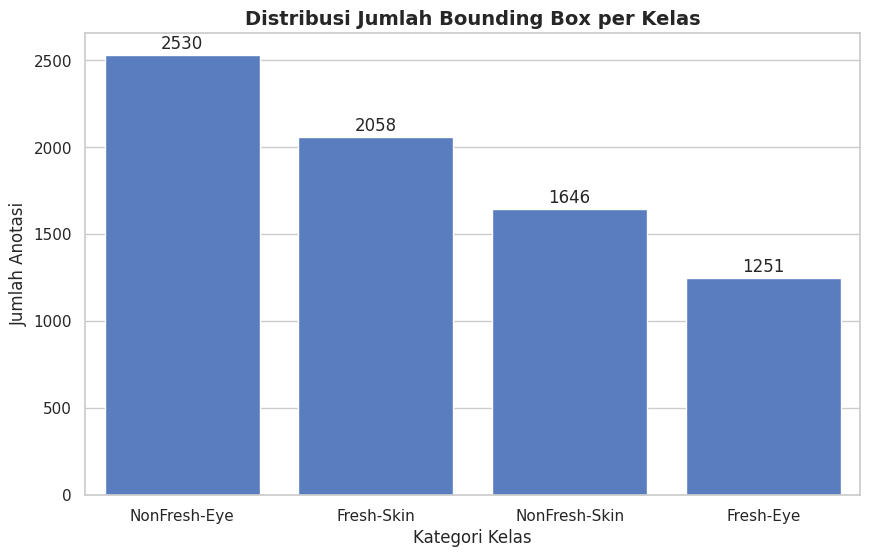

In [4]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_labels, x="Class", order=df_labels["Class"].value_counts().index)
plt.title("Distribusi Jumlah Bounding Box per Kelas", fontsize=14, fontweight='bold')
plt.ylabel("Jumlah Anotasi")
plt.xlabel("Kategori Kelas")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.show()

## 2.3 Analisis Area *Bounding Box*

Plot berhasil disimpan sebagai 'eda_spatial_analysis.png'


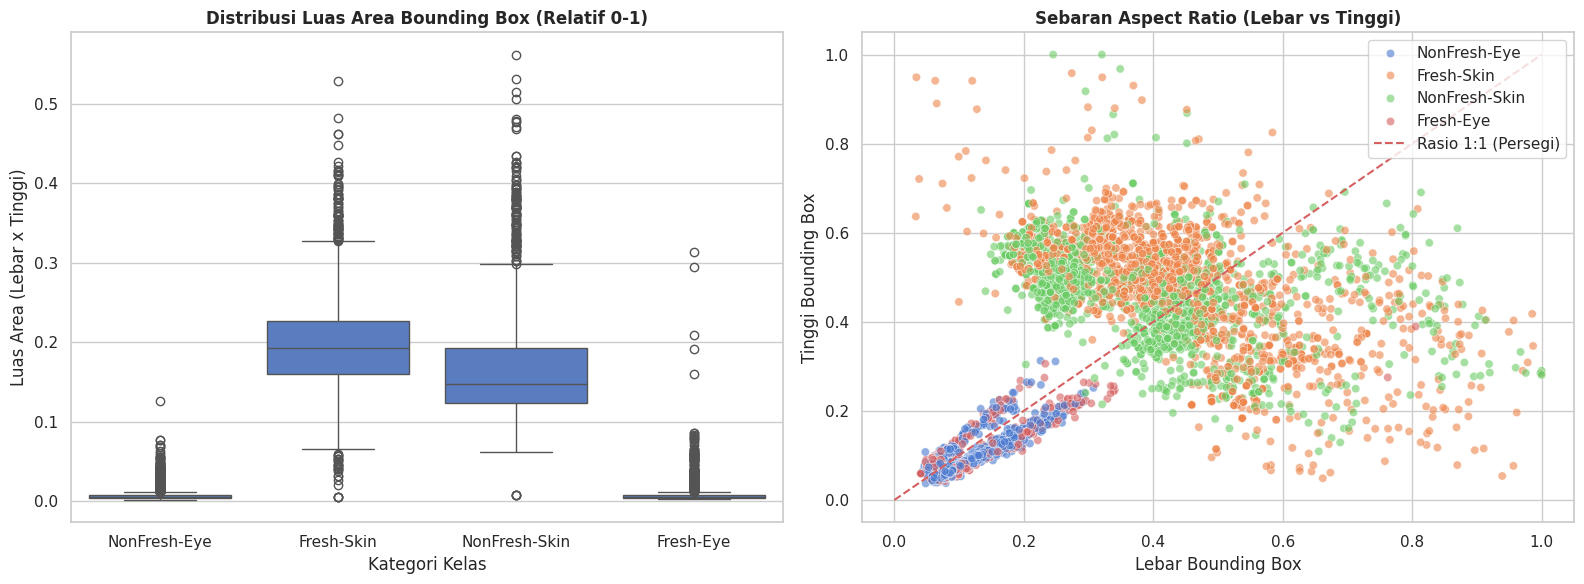

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: distribusi luas area (bbox area)
sns.boxplot(data=df_labels, x="Class", y="Bbox_Area", ax=axes[0])
axes[0].set_title("Distribusi Luas Area Bounding Box (Relatif 0-1)", fontweight='bold')
axes[0].set_ylabel("Luas Area (Lebar x Tinggi)")
axes[0].set_xlabel("Kategori Kelas")

# Plot 2: distribusi aspect ratio
sns.scatterplot(data=df_labels, x="Width", y="Height", hue="Class", alpha=0.6, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'r--', label='Rasio 1:1 (Persegi)') # Garis diagonal panduan
axes[1].set_title("Sebaran Aspect Ratio (Lebar vs Tinggi)", fontweight='bold')
axes[1].set_xlabel("Lebar Bounding Box")
axes[1].set_ylabel("Tinggi Bounding Box")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_spatial_analysis.png", dpi=300, bbox_inches='tight')
print("Plot berhasil disimpan sebagai 'eda_spatial_analysis.png'")
plt.show()

## 2.4 Analisis Integritas Kualitas Data

In [6]:
BASE_DIR = "/kaggle/working/Fish-Freshness-3"
SPLITS = ["train", "valid", "test"]

def get_file_hash(filepath):
    with open(filepath, "rb") as f:
        file_hash = hashlib.md5()
        chunk = f.read(8192)
        while chunk:
            file_hash.update(chunk)
            chunk = f.read(8192)
    return file_hash.hexdigest()

global_hashes = {}
missing_labels_total = 0
cross_split_leakage = []
same_split_duplicates = []

for split in SPLITS:
    img_dir = os.path.join(BASE_DIR, split, "images")
    lbl_dir = os.path.join(BASE_DIR, split, "labels")
    
    if not os.path.exists(img_dir):
        continue
        
    image_files = glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.jpeg"))
    print(f"Memproses partisi '{split}' ({len(image_files)} gambar)...")
    
    for img_path in image_files:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(lbl_dir, f"{base_name}.txt")
        
        # 2.4.1. CEK MISSING ANNOTATION
        if not os.path.exists(label_path):
            missing_labels_total += 1
            
        # 2.4.2 CEK DUPLIKASI DAN DATA LEAKAGE
        img_hash = get_file_hash(img_path)
        
        if img_hash in global_hashes:
            original_split = global_hashes[img_hash]['split']
            original_path = global_hashes[img_hash]['path']
            
            if original_split != split:
                cross_split_leakage.append((original_split, split, base_name))
            else:
                same_split_duplicates.append((split, base_name))
        else:
            global_hashes[img_hash] = {'path': img_path, 'split': split}

print("\n" + "="*50)
print("HASIL AUDIT KUALITAS DATA")
print("="*50)
print(f"- Gambar tanpa label (total dari semua folder) : {missing_labels_total}")
print(f"- Duplikat di dalam partisi yang sama          : {len(same_split_duplicates)}")
print(f"- Kebocoran data antarpartisi (data leakage)   : {len(cross_split_leakage)}")

if len(cross_split_leakage) > 0:
    print("\nDitemukan data leakage pada file berikut:")
    for leak in cross_split_leakage[:5]: # Tampilkan max 5
        print(f"    - Gambar '{leak[2]}' bocor dari folder '{leak[0]}' ke '{leak[1]}'")
else:
    print("\n✅ Dataset bersih, tidak ada data leakage antar partisi train/val/test.")

Memproses partisi 'train' (3788 gambar)...
Memproses partisi 'valid' (475 gambar)...
Memproses partisi 'test' (474 gambar)...

HASIL AUDIT KUALITAS DATA
- Gambar tanpa label (total dari semua folder) : 0
- Duplikat di dalam partisi yang sama          : 0
- Kebocoran data antarpartisi (data leakage)   : 0

✅ Dataset bersih, tidak ada data leakage antar partisi train/val/test.


# **3. Pelatihan Model**

In [7]:
model = YOLO('yolov8s.pt') 

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,  
    imgsz=800,
    batch=16,
    patience=15,
    name='yolov8s-model',
    
    # Augmentasi
    degrees=15.0,
    hsv_s=0.5,
    hsv_v=0.4,
    fliplr=0.5,
    mosaic=1.0,
    copy_paste=0.3,
    mixup=0.2, 
    
    # Pengaturan Belajar
    cos_lr=True,
    lr0=0.001,

    # Optimizer & Regularisasi
    optimizer='AdamW',
    weight_decay=0.0005,
    warmup_epochs=3,
    
    # Ekstra Tekstur & Warna
    bgr=0.1,
)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.1, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/Fish-Freshness-3/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s-model, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_m

# **4. Evaluasi**


4.1 Normalized Confusion Matrix:


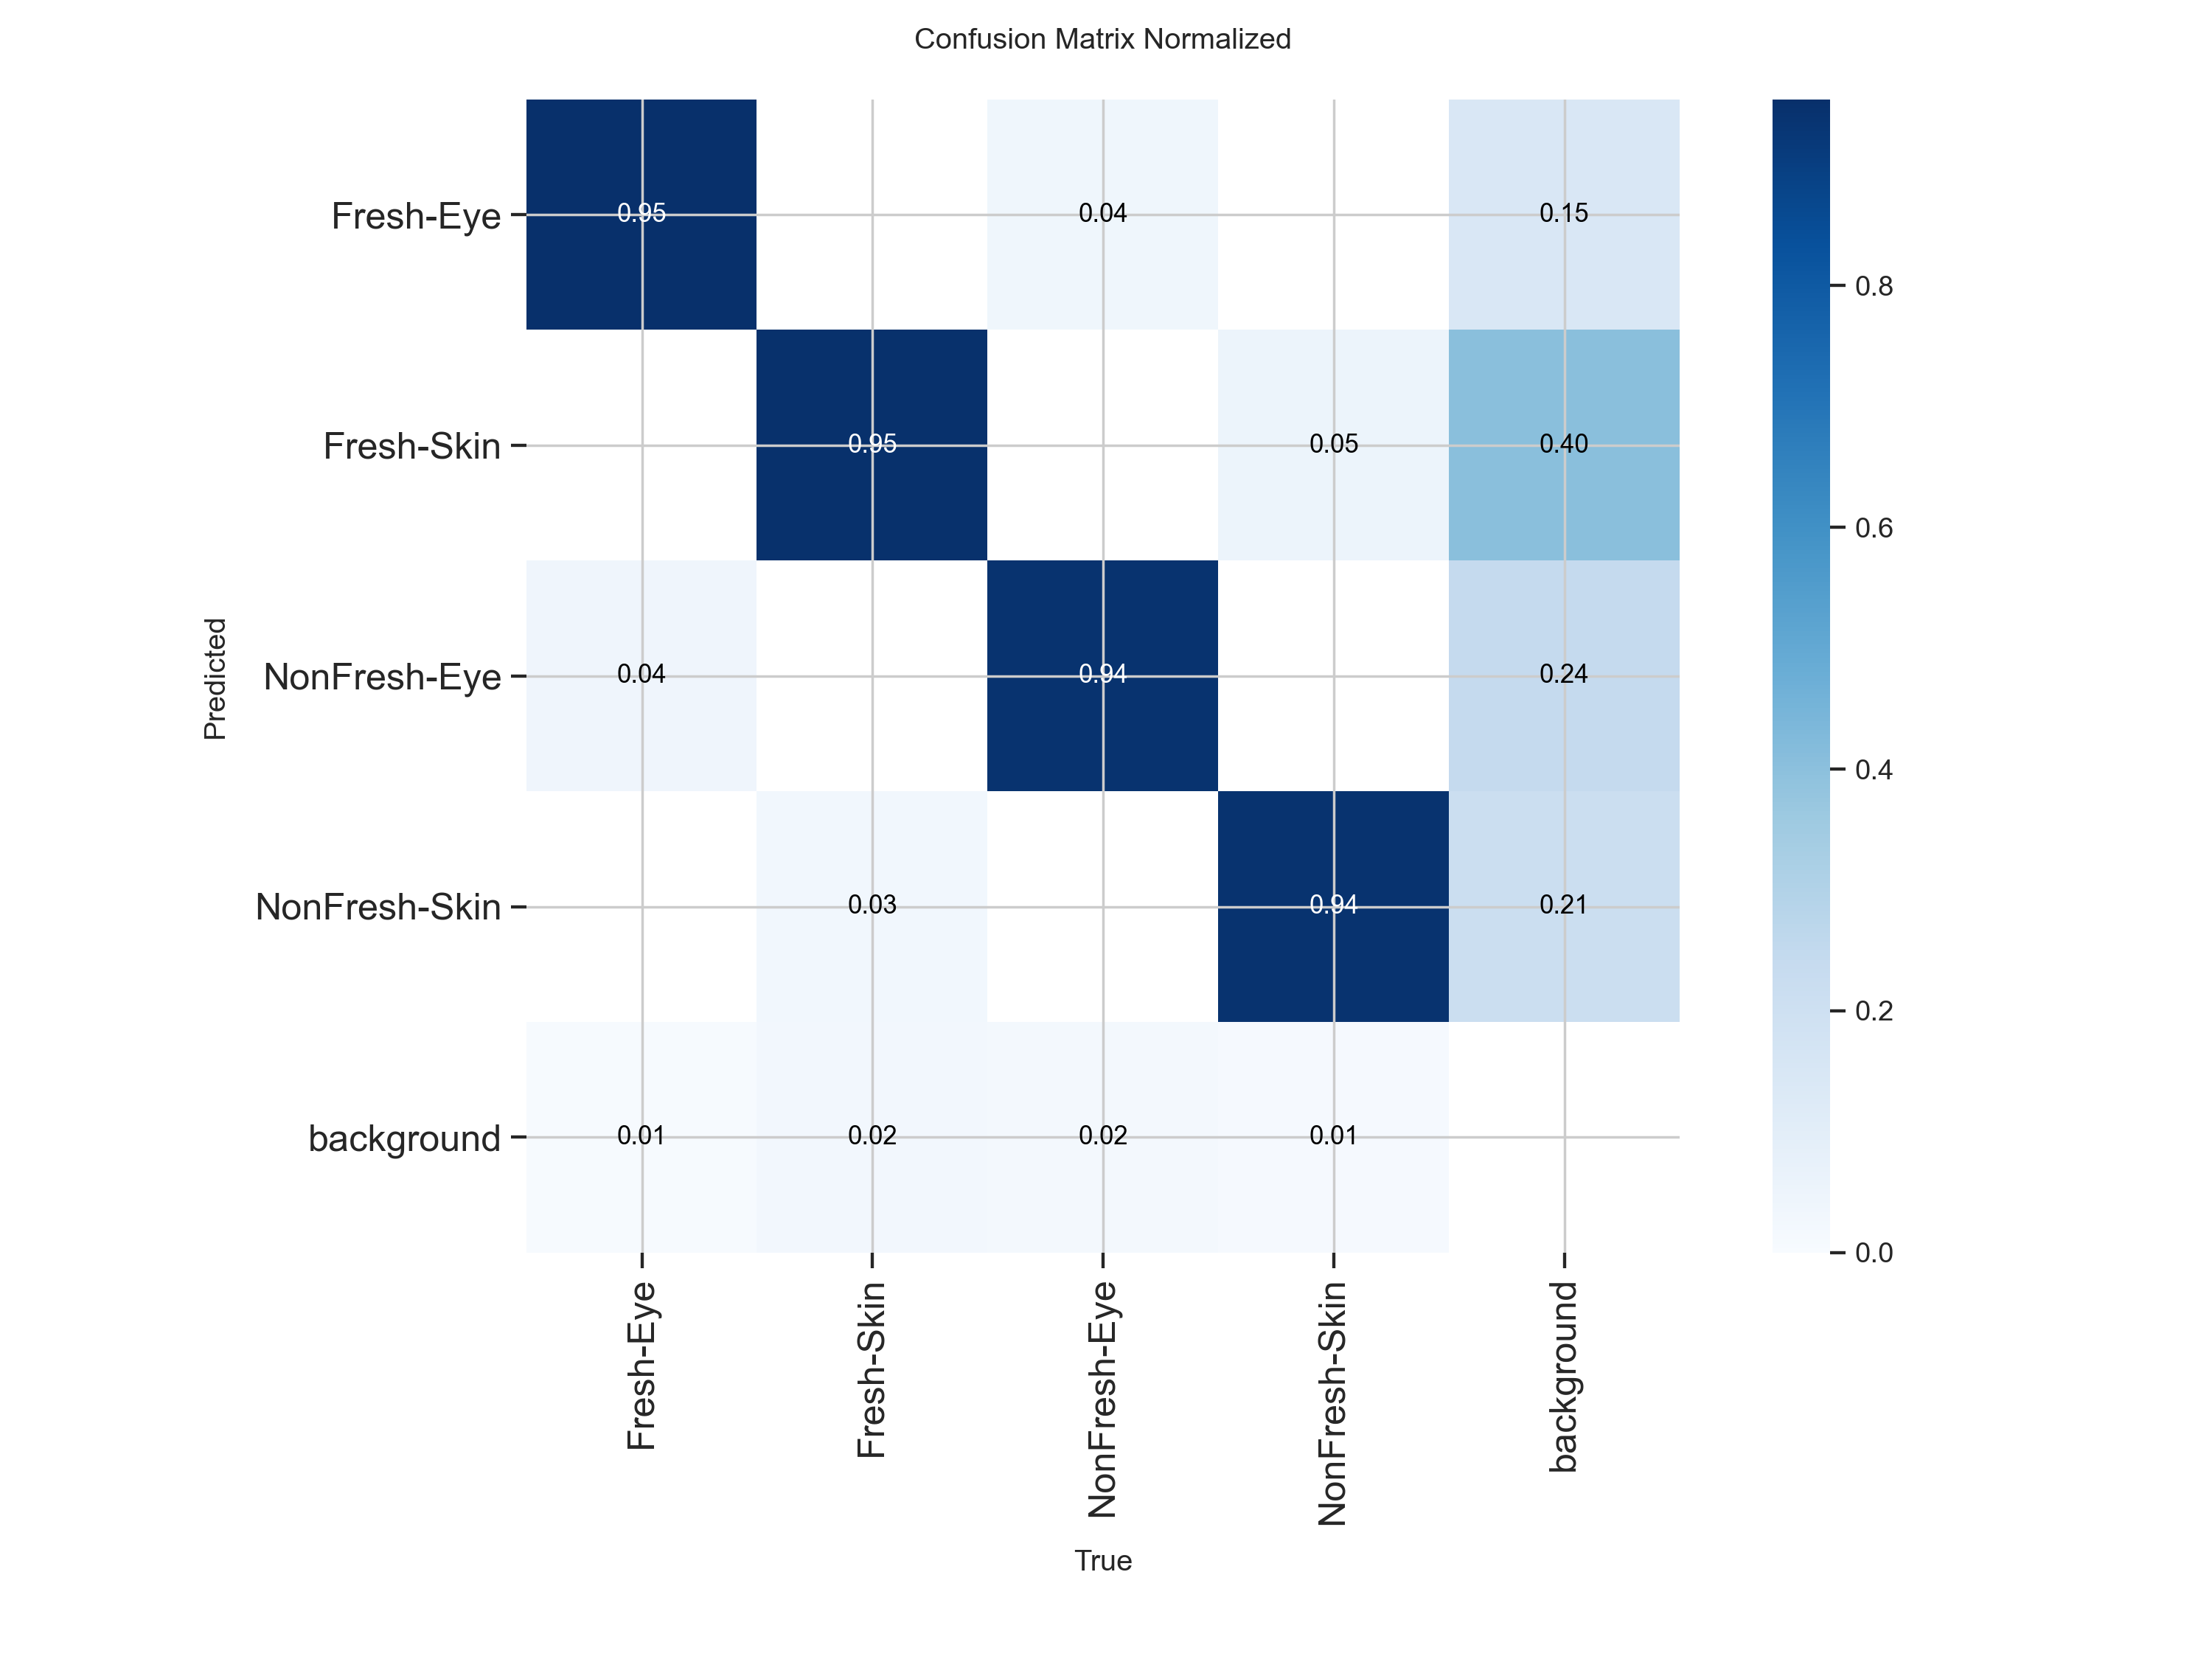


4.2 Kurva F1-Score (Confidence vs F1):


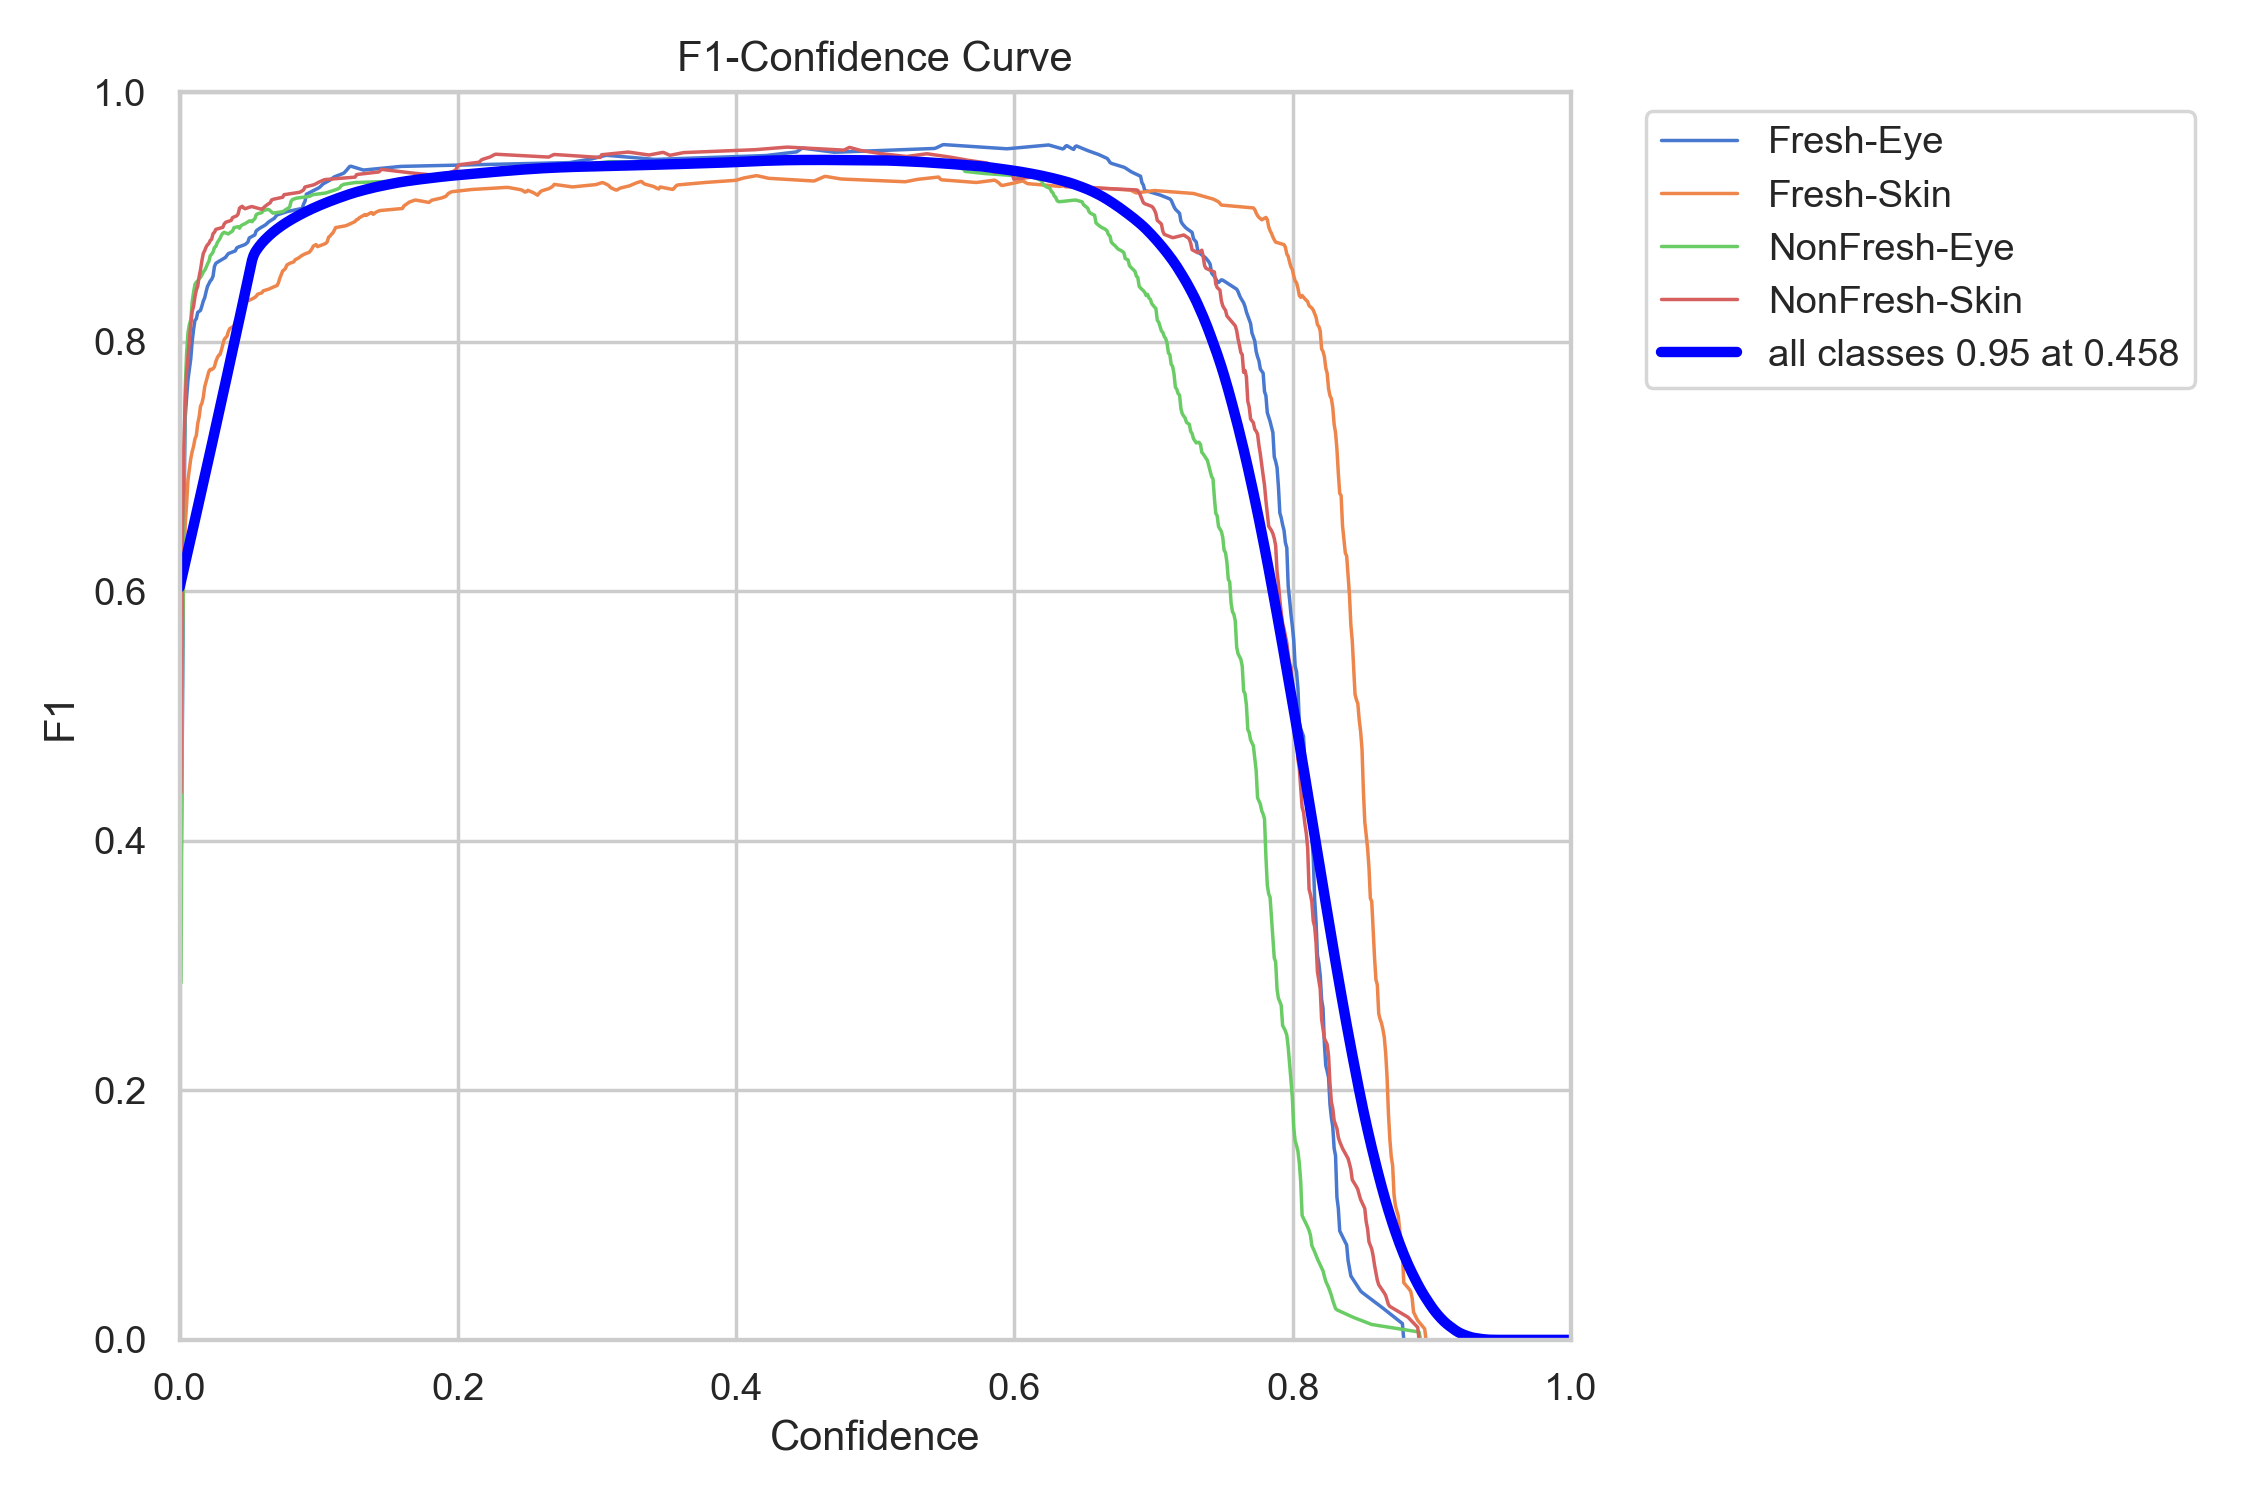


4.3 Rangkuman Metrik Akhir (berdasarkan model terbaik):
- Epoch Terbaik : Epoch ke-48
- mAP50         : 0.9707 (97.07%)
- mAP50-95      : 0.6499 (64.99%)
- Precision     : 0.9479 (94.79%)
- Recall        : 0.9436 (94.36%)
- F1-Score      : 0.9458 (94.58%)


In [8]:
RUN_DIR = "/kaggle/working/runs/detect/yolov8s-model"

cm_path = os.path.join(RUN_DIR, "confusion_matrix_normalized.png")
if os.path.exists(cm_path):
    print("\n4.1 Normalized Confusion Matrix:")
    display(Image(filename=cm_path, width=700))

f1_path = os.path.join(RUN_DIR, "BoxF1_curve.png")
if os.path.exists(f1_path):
    print("\n4.2 Kurva F1-Score (Confidence vs F1):")
    display(Image(filename=f1_path, width=700))

csv_path = os.path.join(RUN_DIR, "results.csv")
if os.path.exists(csv_path):
    print("\n4.3 Rangkuman Metrik Akhir (berdasarkan model terbaik):")
    
    df_results = pd.read_csv(csv_path)
    df_results.columns = df_results.columns.str.strip()
    
    best_epoch_idx = df_results['metrics/mAP50-95(B)'].idxmax()
    best_metrics = df_results.iloc[best_epoch_idx]
    
    mAP50 = best_metrics['metrics/mAP50(B)']
    mAP50_95 = best_metrics['metrics/mAP50-95(B)']
    precision = best_metrics['metrics/precision(B)']
    recall = best_metrics['metrics/recall(B)']
    best_epoch_num = int(best_metrics['epoch']) if 'epoch' in best_metrics else best_epoch_idx + 1
    
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)
    
    print(f"- Epoch Terbaik : Epoch ke-{best_epoch_num}")
    print(f"- mAP50         : {mAP50:.4f} ({mAP50*100:.2f}%)")
    print(f"- mAP50-95      : {mAP50_95:.4f} ({mAP50_95*100:.2f}%)")
    print(f"- Precision     : {precision:.4f} ({precision*100:.2f}%)")
    print(f"- Recall        : {recall:.4f} ({recall*100:.2f}%)")
    print(f"- F1-Score      : {f1_score:.4f} ({f1_score*100:.2f}%)")
else:
    print("\nFile results.csv tidak ditemukan.")

# **Inferensi**

MEMULAI PENGUJIAN INFERENSI (VALIDATION SET)
Memuat bobot model dari: /kaggle/working/runs/detect/yolov8s-model/weights/best.pt
Melakukan inferensi pada gambar: IMG_5973_jpeg.rf.db33f2b6a826523253f375c6921300a3.jpg


image 1/1 /kaggle/working/Fish-Freshness-3/valid/images/IMG_5973_jpeg.rf.db33f2b6a826523253f375c6921300a3.jpg: 608x800 1 Fresh-Eye, 1 Fresh-Skin, 47.5ms
Speed: 4.1ms preprocess, 47.5ms inference, 1.3ms postprocess per image at shape (1, 3, 608, 800)
DETAIL DETEKSI BOUNDING BOX:
----------------------------------------
- Kelas     : Fresh-Skin
- Confidence: 85.64%
- Koordinat : Titik Atas-Kiri (618.0, 516.6) | Titik Bawah-Kanan (2897.6, 1782.7)
----------------------------------------
- Kelas     : Fresh-Eye
- Confidence: 78.32%
- Koordinat : Titik Atas-Kiri (3593.1, 777.7) | Titik Bawah-Kanan (3825.6, 995.0)
----------------------------------------


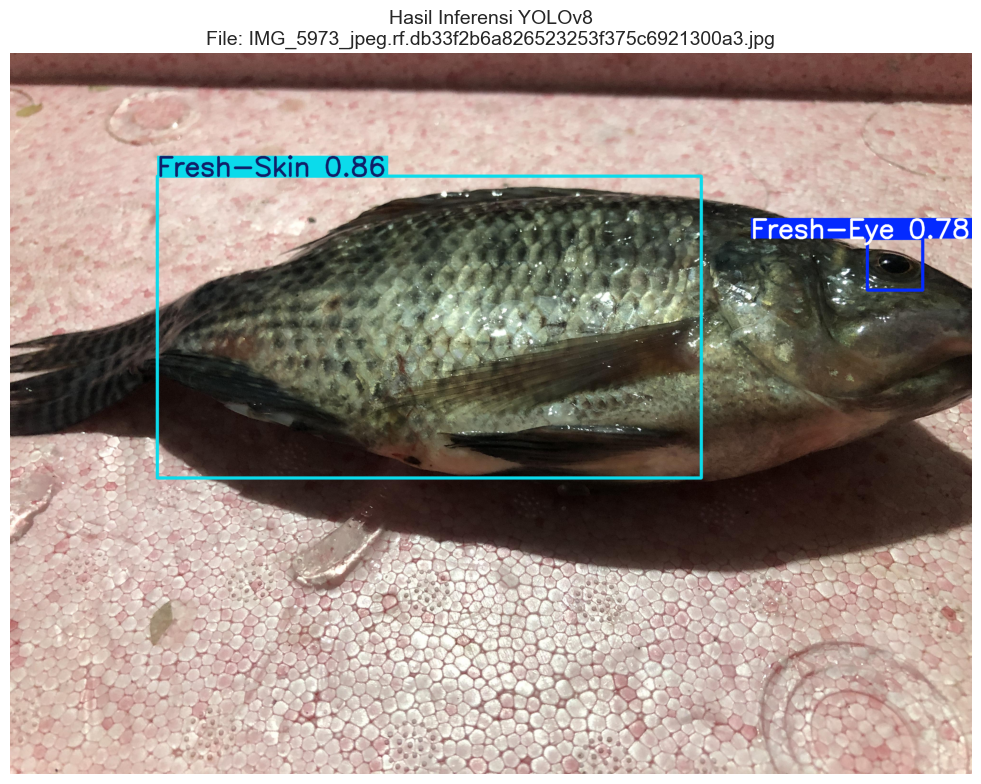


Gambar inferensi berhasil disimpan sebagai 'inference_IMG_5973_jpeg.rf.db33f2b6a826523253f375c6921300a3.png'


In [9]:
MODEL_PATH = "/kaggle/working/runs/detect/yolov8s-model/weights/best.pt" 
VALID_DIR = "/kaggle/working/Fish-Freshness-3/valid/images"

print("MEMULAI PENGUJIAN INFERENSI (VALIDATION SET)")
print("="*50)

print(f"Memuat bobot model dari: {MODEL_PATH}")
model = YOLO(MODEL_PATH)

image_files = glob.glob(os.path.join(VALID_DIR, "*.jpg")) + glob.glob(os.path.join(VALID_DIR, "*.jpeg"))

if not image_files:
    print("Error: Tidak ada gambar di folder validasi.")
else:
    sample_img_path = random.choice(image_files)
    img_name = os.path.basename(sample_img_path)
    print(f"Melakukan inferensi pada gambar: {img_name}\n")

    results = model.predict(source=sample_img_path, conf=0.25, save=False)
    result = results[0]

    print("DETAIL DETEKSI BOUNDING BOX:")
    print("-" * 40)
    if len(result.boxes) == 0:
        print("Tidak ada objek yang terdeteksi.")
    else:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            conf = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist() 
            
            print(f"- Kelas     : {class_name}")
            print(f"- Confidence: {conf * 100:.2f}%")
            print(f"- Koordinat : Titik Atas-Kiri ({x1:.1f}, {y1:.1f}) | Titik Bawah-Kanan ({x2:.1f}, {y2:.1f})")
            print("-" * 40)

    img_with_boxes = result.plot()
    img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Hasil Inferensi YOLOv8\nFile: {img_name}", fontweight='bold', fontsize=14)
    plt.tight_layout()

    save_filename = f"inference_{os.path.splitext(img_name)[0]}.png"
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"\nGambar inferensi berhasil disimpan sebagai '{save_filename}'")